In [1]:
import numpy as np
from config import *
from meer21cm.mock import HIGalaxySimulation
from meer21cm.util import jy_to_kelvin, pca_clean
import matplotlib.pyplot as plt
from tqdm import trange
from   astropy.io import fits
from   astropy.wcs import WCS
import matplotlib
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,
    "xtick.top": False,
    "ytick.left": True,
    "ytick.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "font.size": 11,
})

with fits.open("data/T_cube_trim.fits") as hdul:
    real_cube = hdul[0].data
    header    = hdul[0].header
    wcs_2d    = WCS(header, naxis=2)

# 参数设置sq
beam_rotation = 0
N_phi = 720
Tsys = 17

Use_counts = True
Use_poisson = False

sky_components = "f1s1d1c1NVSS"
theta_max = 90
SN = "N"

In [2]:
# 文件路径
mock_fits_file = (
    f"dirk_wcs_map/"
    f"dirk_wcs_{SN}{N_phi}"
    f"_sp{beam_rotation}_"
    f"theta{theta_max}_"
    f"{sky_components}.fits"
)

In [3]:
ps_mock = HIGalaxySimulation(
    map_file=mock_fits_file,
    counts_file=counts_file,
    cosmo=cosmo,
    gal_file=gal_file,
    ra_range=ra_range_MK,
    dec_range=dec_range_MK,
    survey="meerklass_2021",
    band="L",
)

ps_real = HIGalaxySimulation(
    map_file="/idia/projects/meerklass/MEERKLASS-2/Lband_2021/level6/Nscan961_Tsky_cube_p0.3d_sigma4.0_iter2.fits",
    counts_file=counts_file,
    cosmo=cosmo,
    gal_file=gal_file,
    ra_range=ra_range_MK,
    dec_range=dec_range_MK,
    survey="meerklass_2021",
    band="L",
)

In [4]:
# 读取 HI map
ps_real.read_from_fits()
ps_mock.read_from_fits()

NoiseStd = Tsys / np.sqrt(2 * 2 * 0.2 * 1e6)
Counts = ps_mock.counts.copy()
Counts[Counts == 0] = np.inf
noise = ps_mock.create_white_noise_map(
    NoiseStd,
    counts=Counts,
    seed=71,
    inf_to_zero=True,
)

mock_cube0 = ps_mock.data.copy()
ps_mock.data += noise
mock_cubeN = mock_cube0+noise

In [5]:
# 单位转换：Jy -> K
jy_k_coeff = jy_to_kelvin(
    1,
    ps_real.pixel_area * (np.pi / 180) ** 2,
    ps_real.nu,
)

# 保存不同 N_fg 对应的结果
Clean_Mock_Cube_List = []
A_Mock_Mat_List = []
Clean_Real_Cube_List = []
A_Real_Mat_List = []

for N_pca in trange(0, 16):
    clean_mock_cube, A_mock_mat_data, covariance_mock, eignumb_mock, eigenval_mock, V_mock  = pca_clean(
        signal=ps_mock.data / jy_k_coeff[None, None],
        N_fg=N_pca,
        weights=ps_mock.W_HI,
        mean_center=False,
        return_A=True,
        ignore_nan=True,
        return_analysis = True
    )
    clean_real_cube, A_real_mat_data, covariance_real, eignumb_real, eigenval_real, V_real  = pca_clean(
        signal=ps_real.data / jy_k_coeff[None, None],
        N_fg=N_pca,
        weights=ps_real.W_HI,
        mean_center=False,
        return_A=True,
        ignore_nan=True,
        return_analysis = True
    )
    Clean_Mock_Cube_List.append(clean_mock_cube)
    Clean_Real_Cube_List.append(clean_real_cube)
    A_Mock_Mat_List.append(A_mock_mat_data)
    A_Real_Mat_List.append(A_real_mat_data)

100%|██████████| 16/16 [00:31<00:00,  2.00s/it]


In [6]:
# 提取 real cube 的第11个 PCA mode
n_mode = 10
Real_Mode_cube = (
    Clean_Real_Cube_List[n_mode-1]
    - Clean_Real_Cube_List[n_mode]
)
# 提取 mock cube 的第5个 PCA mode
Mock_Mode_cube = (
    Clean_Mock_Cube_List[n_mode-1]
    - Clean_Mock_Cube_List[n_mode]
)

Real spectrum std = 1.7550e-05
Mock spectrum std = 6.7984e-05


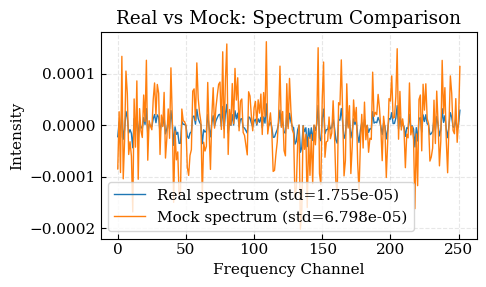

In [7]:
freq_spec_1 = Real_Mode_cube[73, 43, :]
freq_spec_2 = Real_Mode_cube[73, 29, :]

Real_STD = np.std(freq_spec_1)
Mock_STD = np.std(freq_spec_2)

print(f"Real spectrum std = {Real_STD:.4e}")
print(f"Mock spectrum std = {Mock_STD:.4e}")

plt.figure(figsize=(5, 3))

plt.plot(
    freq_spec_1,
    label=f"Real spectrum (std={Real_STD:.3e})",
    linewidth=1.,
)
plt.plot(
    freq_spec_2,
    label=f"Mock spectrum (std={Mock_STD:.3e})",
    linewidth=1.,
)

plt.title("Real vs Mock: Spectrum Comparison")
plt.xlabel("Frequency Channel")
plt.ylabel("Intensity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

channel = 42, freq = 979927734.375 Hz


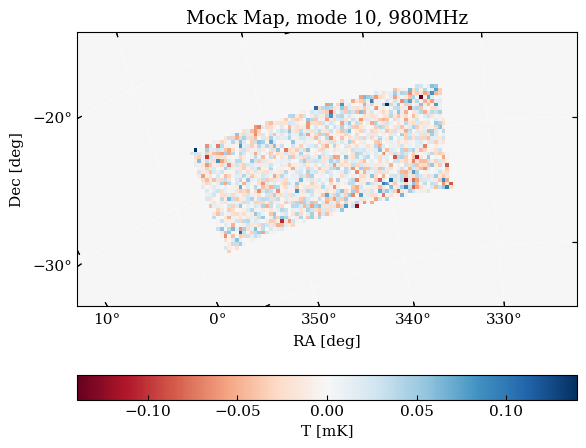

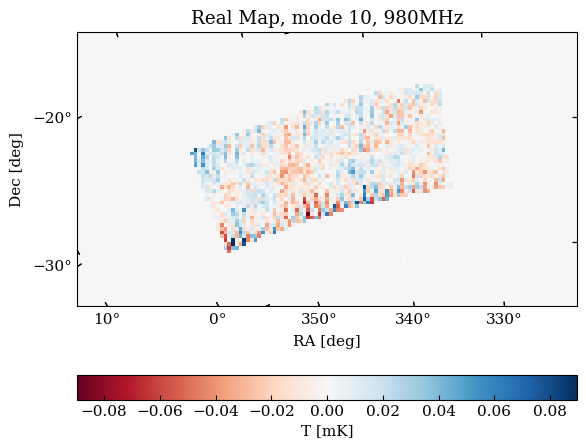

In [8]:
Target_Frequency = 980 
i_frequency = np.argmin(np.abs(ps_mock.nu - Target_Frequency* 1e6))

print(f"channel = {i_frequency}, freq = {ps_mock.nu[i_frequency]:.3f} Hz")

# 取出同一个频率通道下的二维图像
Mock_Map = Mock_Mode_cube[:, :, i_frequency].T*1000 #转到mK
Real_Map = Real_Mode_cube[:, :, i_frequency].T*1000 #转到mK

# Mock 图颜色范围

mock_limit = min(
    np.abs(Mock_Map.min()),
    np.abs(Mock_Map.max()),
)

mock_vmin = -mock_limit
mock_vmax = mock_limit

real_limit = min(
    np.abs(Real_Map.min()),
    np.abs(Real_Map.max()),
)

real_vmin = -real_limit
real_vmax = real_limit


fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": wcs_2d})
im = ax.imshow(
    Mock_Map,
    origin="lower",
    cmap="RdBu",
    vmin = mock_vmin,
    vmax = mock_vmax
)
ax.coords[0].set_format_unit("deg")
ax.invert_xaxis()
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Mock Map, mode "+str(n_mode)+", "+str(Target_Frequency)+"MHz")
ax.coords.grid(True, color="white", ls="--", alpha=0.5)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.15)
cbar.set_label("T [mK]")

plt.tight_layout()
plt.show()

# 绘制 Real 图
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": wcs_2d})

im = ax.imshow(
    Real_Map,
    origin="lower",
    cmap="RdBu",
    vmin = real_vmin,
    vmax = real_vmax
)

ax.coords[0].set_format_unit("deg")
ax.invert_xaxis()
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Real Map, mode "+str(n_mode)+", "+str(Target_Frequency)+"MHz")
ax.coords.grid(True, color="white", ls="--", alpha=0.5)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.15)
cbar.set_label("T [mK]")

plt.tight_layout()
plt.show()

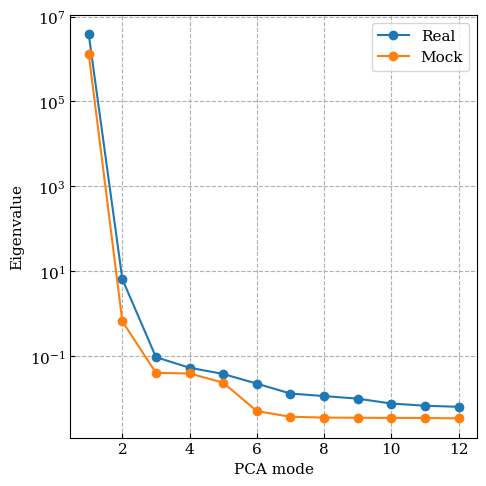

In [9]:
Modes = np.arange(1, 13)

plt.figure(figsize=(5, 5))

plt.plot(
    Modes,
    eigenval_real[:12],
    marker="o",
    label="Real",
)

plt.plot(
    Modes,
    eigenval_mock[:12],
    marker="o",
    label="Mock",
)

plt.xlabel("PCA mode")
plt.ylabel("Eigenvalue")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

channel = 90, freq = 989958984.375 Hz


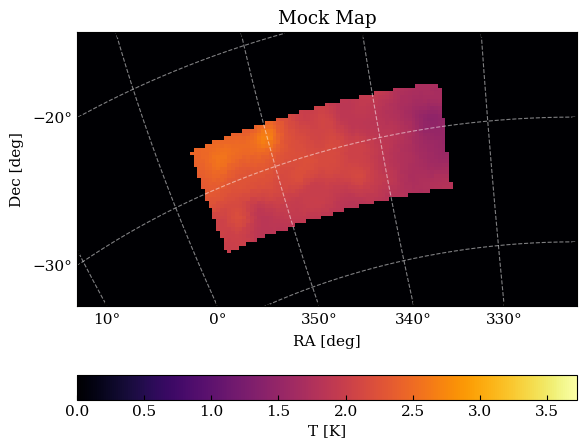

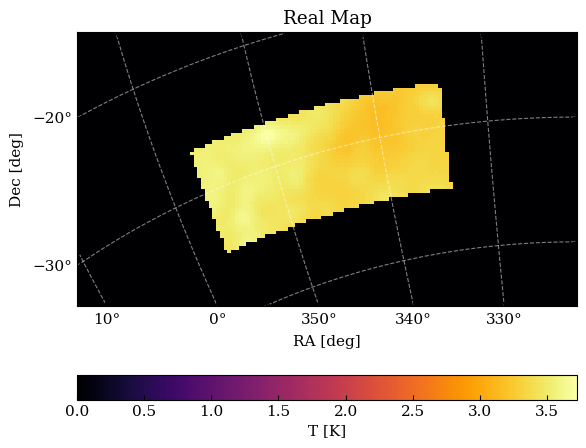

In [10]:
# 找到最接近 990 MHz 的频率通道
Target_Frequency = 990 * 1e6
i_frequency = np.argmin(np.abs(ps_mock.nu - Target_Frequency))

print(f"channel = {i_frequency}, freq = {ps_mock.nu[i_frequency]:.3f} Hz")

# 取出同一个频率通道下的二维图像
Mock_Map = ps_mock.data[:, :, i_frequency].T
Real_Map = ps_real.data[:, :, i_frequency].T

# 统一颜色范围
vmin = min(np.nanmin(Mock_Map), np.nanmin(Real_Map))
vmax = max(np.nanmax(Mock_Map), np.nanmax(Real_Map))

# 绘制 Mock 图
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": wcs_2d})

im = ax.imshow(
    Mock_Map,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

ax.coords[0].set_format_unit("deg")
ax.invert_xaxis()
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Mock Map")
ax.coords.grid(True, color="white", ls="--", alpha=0.5)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.15)
cbar.set_label("T [K]")

plt.tight_layout()
plt.show()

# 绘制 Real 图
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": wcs_2d})

im = ax.imshow(
    Real_Map,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

ax.coords[0].set_format_unit("deg")
ax.invert_xaxis()
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Real Map")
ax.coords.grid(True, color="white", ls="--", alpha=0.5)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.15)
cbar.set_label("T [K]")

plt.tight_layout()
plt.show()

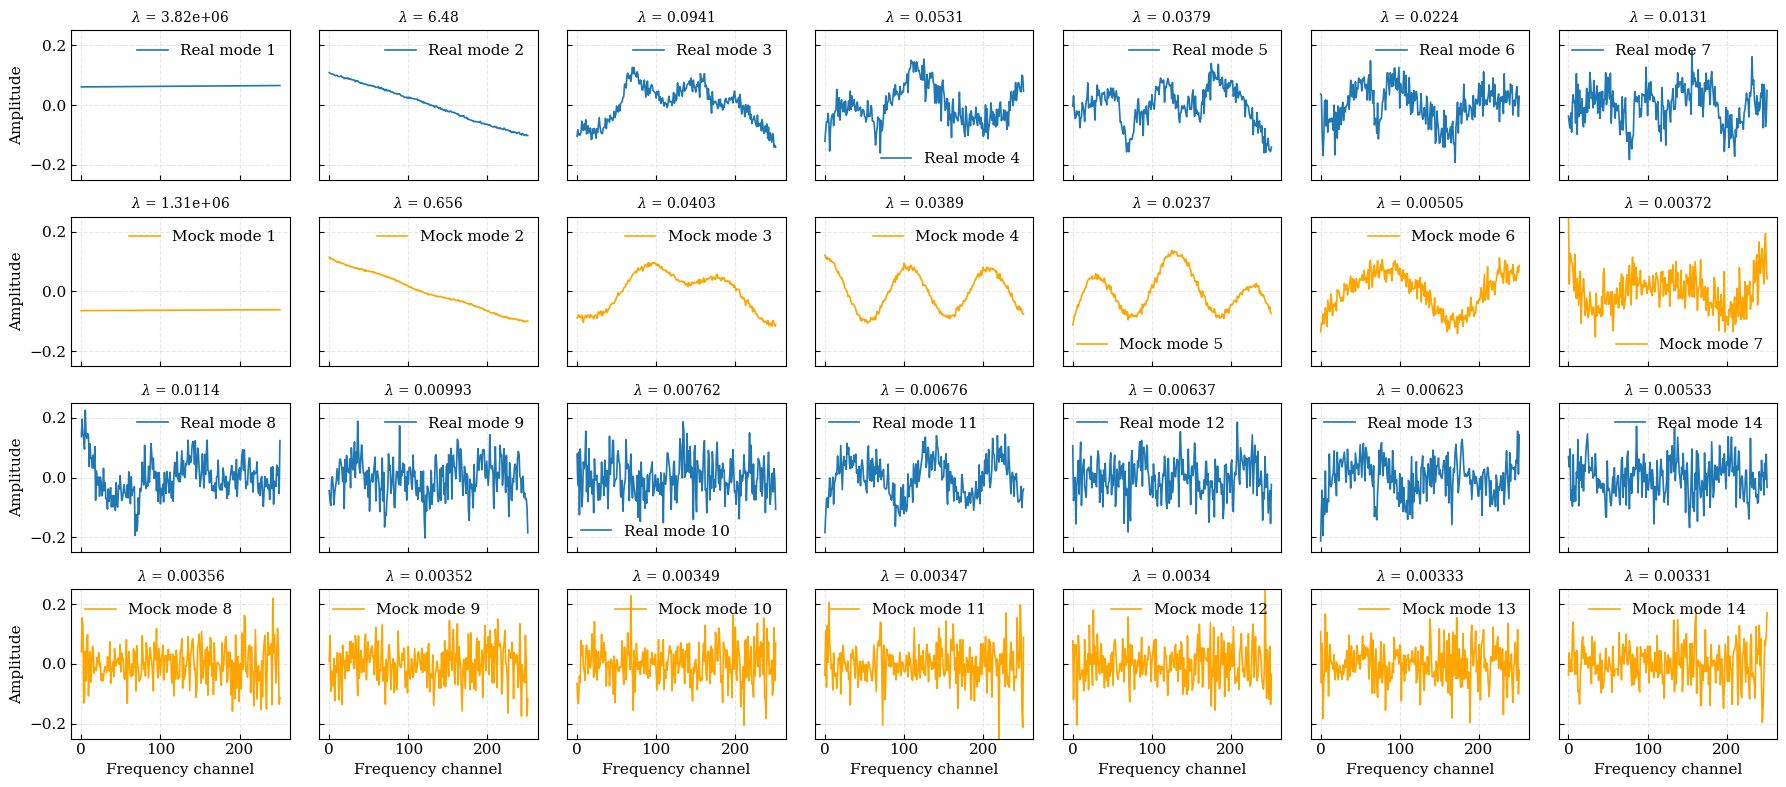

In [11]:
N_modes = 14

fig, axes = plt.subplots(
    4,
    7,
    figsize=(18, 8),
    sharex=True,
    sharey=True,
)

for i_mode in range(N_modes):
    v_mock = A_Mock_Mat_List[N_pca][:, i_mode]
    v_real = A_Real_Mat_List[N_pca][:, i_mode]
    i_col = i_mode % 7

    if i_mode < 7:
        i_real_row = 0
        i_mock_row = 1
    else:
        i_real_row = 2
        i_mock_row = 3

    # 绘制 Real
    ax_real = axes[i_real_row, i_col]

    ax_real.plot(
        v_real,
        label=f"Real mode {i_mode + 1}",
        linewidth=1.2,
    )
    ax_real.set_title(
    f"$\\lambda$ = {eigenval_real[i_mode]:.3g}",
    fontsize=10,
    )

    ax_real.legend(frameon=False)
    ax_real.grid(alpha=0.3)
    ax_real.set_ylim(-0.25, 0.25)

    # 绘制 Mock
    ax_mock = axes[i_mock_row, i_col]
    
    if np.corrcoef(v_real, v_mock)[0, 1] < 0:
        v_mock *= -1
    ax_mock.plot(
        v_mock,
        label=f"Mock mode {i_mode + 1}",
        linewidth=1.2,
        color="orange",
    )
    ax_mock.set_title(
    f"$\\lambda$ = {eigenval_mock[i_mode]:.3g}",
    fontsize=10,
    )

    ax_mock.legend(frameon=False)
    ax_mock.grid(alpha=0.3)
    ax_mock.set_ylim(-0.25, 0.25)

# 设置纵轴标签
for i_row in range(4):
    axes[i_row, 0].set_ylabel("Amplitude")

# 设置横轴标签
for ax in axes[-1, :]:
    ax.set_xlabel("Frequency channel")

plt.tight_layout()
plt.show()

channel = 90, freq = 989958984.375 Hz


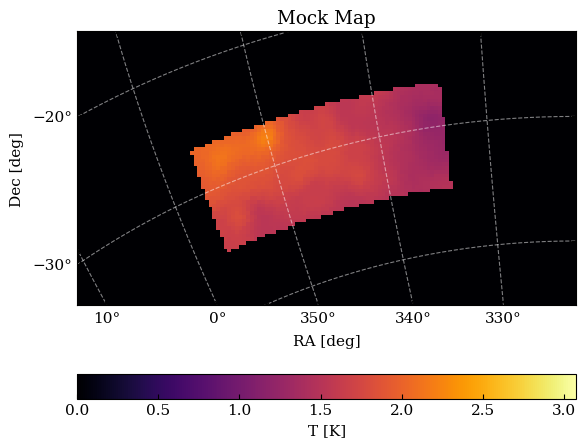

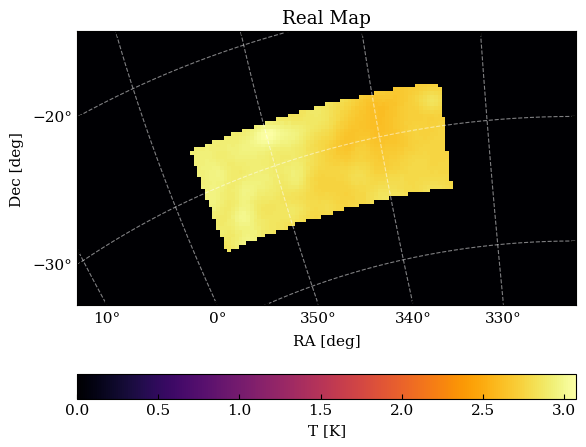

In [12]:
# 选择 PCA 分量编号
N_pca = 0

# 找到最接近 990 MHz 的频率通道
Target_Frequency = 990 * 1e6
i_frequency = np.argmin(np.abs(ps_mock.nu - Target_Frequency))

print(f"channel = {i_frequency}, freq = {ps_mock.nu[i_frequency]:.3f} Hz")

# 取出同一个频率通道下的二维图像
Mock_Map = Clean_Mock_Cube_List[N_pca][:, :, i_frequency].T
Real_Map = Clean_Real_Cube_List[N_pca][:, :, i_frequency].T

# 统一颜色范围
vmin = min(np.nanmin(Mock_Map), np.nanmin(Real_Map))
vmax = max(np.nanmax(Mock_Map), np.nanmax(Real_Map))

# 绘制 Mock 图
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": wcs_2d})

im = ax.imshow(
    Mock_Map,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

ax.coords[0].set_format_unit("deg")
ax.invert_xaxis()
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Mock Map")
ax.coords.grid(True, color="white", ls="--", alpha=0.5)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.15)
cbar.set_label("T [K]")

plt.tight_layout()
plt.show()

# 绘制 Real 图
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": wcs_2d})

im = ax.imshow(
    Real_Map,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

ax.coords[0].set_format_unit("deg")
ax.invert_xaxis()
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Real Map")
ax.coords.grid(True, color="white", ls="--", alpha=0.5)

cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.15)
cbar.set_label("T [K]")

plt.tight_layout()
plt.show()

看起来simulation和real data的一大区别就在这些被mask掉的像素.
为什么原来全为0的像素在pca后不再全0了? 原来是因为做了中心化.

In [19]:
x = np.linspace(0,5,100)

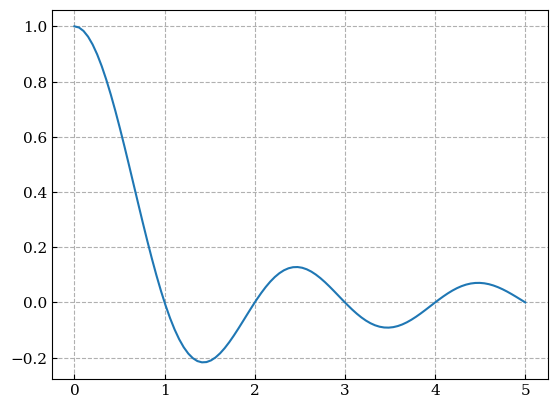

In [20]:
plt.plot(x, np.sinc(x))